В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import roc_auc_score, roc_curve
from process_bank_churn import preprocess_data, preprocess_test_data
from sklearn.model_selection import GridSearchCV, train_test_split,RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv('../Competition/train.csv')
df_test = pd.read_csv('../Competition/test.csv')
target_col = 'Exited'

In [14]:
X_train, X_val, y_train, y_val, feature_names, scaler, encoder = preprocess_data(df, target_col)

1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

In [20]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_prob_val = knn.predict_proba(X_val)[:, 1]
y_prob_train = knn.predict_proba(X_train)[:, 1]
auc_score_val = roc_auc_score(y_val, y_prob_val)
auc_score_train = roc_auc_score(y_train, y_prob_train)
print(f'ROC AUC Score (Validation): {auc_score_val:.4f}')
print(f'ROC AUC Score (Training): {auc_score_train:.4f}')


ROC AUC Score (Validation): 0.8338
ROC AUC Score (Training): 0.9461


Модель не дуже хороша, є високий bias

2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [22]:
knn = KNeighborsClassifier()
params_knn = {'n_neighbors': np.arange(1, 25)}
knn_gs = GridSearchCV(knn, params_knn, cv=5)
knn_gs.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': array([ 1, 2..., 22, 23, 24])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and cand

In [23]:
knn_best = knn_gs.best_estimator_

print(knn_gs.best_params_, knn_gs.best_score_)
y_prob_val = knn_best.predict_proba(X_val)[:, 1]
y_prob_train = knn_best.predict_proba(X_train)[:, 1]
auc_score_val = roc_auc_score(y_val, y_prob_val)
auc_score_train = roc_auc_score(y_train, y_prob_train)
print(f'ROC AUC Score (Validation): {auc_score_val:.4f}')
print(f'ROC AUC Score (Training): {auc_score_train:.4f}')

{'n_neighbors': np.int64(7)} 0.8522500000000001
ROC AUC Score (Validation): 0.8450
ROC AUC Score (Training): 0.9354


Трохи краще ніж попередня моедль але все ще є андерфітінг

3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [ ]:
import time
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(random_state=42)
params_dtc = {'max_depth': np.arange(1, 20,2),'max_leaf_nodes': np.arange(2, 10)}

start = time.perf_counter()
dtc_gs = GridSearchCV(dtc, params_dtc, cv=3, scoring='roc_auc')

dtc_gs.fit(X_train, y_train)
end = time.perf_counter()

print(end - start)
dtc_best = dtc_gs.best_estimator_



7.898321799999394


In [35]:
print(dtc_gs.best_params_)

{'max_depth': np.int64(5), 'max_leaf_nodes': np.int64(9)}


In [28]:

y_prob_val_dtc = dtc_best.predict_proba(X_val)[:, 1]
y_prob_train_dtc = dtc_best.predict_proba(X_train)[:, 1]
auc_score_val_dtc = roc_auc_score(y_val, y_prob_val_dtc)
auc_score_train_dtc = roc_auc_score(y_train, y_prob_train_dtc)
print(f'ROC AUC Score (Validation): {auc_score_val_dtc:.4f}')
print(f'ROC AUC Score (Training): {auc_score_train_dtc:.4f}')

ROC AUC Score (Validation): 0.8944
ROC AUC Score (Training): 0.8973


AUROC майже не відрізняється між вибірками, модель краще ніж модель knn

4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [55]:
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20,25],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [58]:
dtc_random = RandomizedSearchCV(dtc, params_dt, n_iter=40, cv=3, scoring='roc_auc', random_state=42)
dtc_random.fit(X_train, y_train)
dtc_random_best = dtc_random.best_estimator_
y_prob_val_dtc_random = dtc_random_best.predict_proba(X_val)[:, 1]
y_prob_train_dtc_random = dtc_random_best.predict_proba(X_train)[:, 1]
auc_score_val_dtc_random = roc_auc_score(y_val, y_prob_val_dtc_random)
auc_score_train_dtc_random = roc_auc_score(y_train, y_prob_train_dtc_random)
print(f'ROC AUC Score (Validation): {auc_score_val_dtc_random:.4f}')
print(f'ROC AUC Score (Training): {auc_score_train_dtc_random:.4f}')
print(dtc_random.best_params_)

ROC AUC Score (Validation): 0.9180
ROC AUC Score (Training): 0.9185
{'splitter': 'best', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_leaf_nodes': np.int64(18), 'max_features': None, 'max_depth': np.int64(15), 'criterion': 'entropy'}


5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

In [60]:
X_test = preprocess_test_data(['Surname'],df_test, feature_names, scaler, encoder)
test_probs = dtc_random_best.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    'id': df_test['id'],   
    'Exited': test_probs.round(4)
})

submission.to_csv('submission_07032026.csv', index=False)

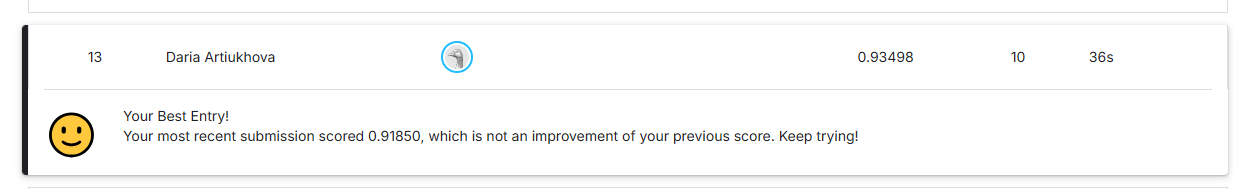